# Step 3 — Affinity Deficit Φ_A (Calculations A1–A3)

**Purpose:** Compute empirical proxies for the affinity deficit objective Φ_A for every memory sequence.

- **A1** — CDR replacement enrichment per sequence: per-sequence Φ_A = −log(δ_RS) where δ_RS = (R_CDR/S_CDR) / RS_neutral. High Φ_A = few beneficial replacements → high affinity deficit. Low/negative Φ_A = excess replacements → strong positive selection.
- **A2** — Convergent/public clonotype analysis: CDRH3 sequences shared across ≥3 donors (convergent evolution driven by antigen). Compare Φ_A, mutation load, and germline usage between public and private clonotypes.
- **A3** — Isotype-stratified affinity proxy: within clonal lineages containing both IgM and IgG/IgA members, identify mutations enriched in class-switched vs unswitched cells. These are candidate affinity-selected mutations.

**Key adaptations from Step 2 findings:**
- CDR1 is under **purifying** selection (ω = 0.74, median). RS_neutral accounts for this by S5F-weighting the expected R/S across both CDR1 and CDR2, so positions under purifying constraint lower RS_neutral below a naive equal-weight estimate.
- VH/VL Vernier co-mutation is absent → Φ_A computed chain-independently.
- Positions with s5f_weight = 0 (Aho43/54) are excluded from RS_neutral to avoid division artefacts.

**Inputs:** `processed/aligned_master.parquet`, `results/tables/omega_per_position.csv`  
**Outputs:** `results/tables/affinity_proxy.parquet`, `results/tables/public_clonotypes.csv`, `results/tables/affinity_selected_mutations.csv`, `results/figures/fig_a1_*.png`, `results/figures/fig_a2_*.png`, `results/figures/fig_a3_*.png`

In [1]:
import polars as pl
import numpy as np
import math
from pathlib import Path
import time

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
DATA_DIR  = Path("/home/jovyan/shared/Benjamin/LineageAtlas/pairplex_paper/")
PROC_DIR  = DATA_DIR / "processed"
RESULTS   = DATA_DIR / "results"
FIGURES   = RESULTS / "figures"
TABLES    = RESULTS / "tables"

MASTER_FILE = PROC_DIR / "aligned_master.parquet"

print("Paths OK")

Paths OK


In [3]:
print("Loading master table...")
master = pl.read_parquet(MASTER_FILE)
KEY = "seq_name"

# Memory = not naive by either definition
memory = master.filter(~pl.col('naive_bio') & ~pl.col('naive_comp'))

print(f"Master: {master.shape}")
print(f"Memory: {memory.height:,}")

# Confirm key columns exist
required = ['n_R_CDR_H', 'n_S_CDR_H', 'n_R_FWR_H', 'n_S_FWR_H',
            'n_R_CDR_L', 'n_S_CDR_L', 'n_mut_H', 'n_mut_L',
            'c_gene:0', 'v_gene:0', 'donor', 'clonotype', 'lineage',
            'junction_aa:0', 'cdrh3_length']
missing = [c for c in required if c not in master.columns]
if missing:
    print(f"MISSING COLUMNS: {missing}")
else:
    print("All required columns present ✓")

# Isotype distribution in memory
print("\nMemory isotype distribution:")
print(
    memory.group_by('c_gene:0')
    .agg(pl.len().alias('n'), pl.col('n_mut_H').mean().alias('mean_n_mut_H'))
    .sort('n', descending=True)
)

Loading master table...
Master: (4269981, 331)
Memory: 1,517,911
All required columns present ✓

Memory isotype distribution:
shape: (13, 3)
┌──────────┬────────┬──────────────┐
│ c_gene:0 ┆ n      ┆ mean_n_mut_H │
│ ---      ┆ ---    ┆ ---          │
│ str      ┆ u32    ┆ f64          │
╞══════════╪════════╪══════════════╡
│ IGHM     ┆ 839304 ┆ 13.768259    │
│ IGHA2    ┆ 377867 ┆ 21.227051    │
│ IGHG2    ┆ 231287 ┆ 21.728766    │
│ null     ┆ 47290  ┆ 13.305752    │
│ IGHG4    ┆ 21086  ┆ 24.591483    │
│ …        ┆ …      ┆ …            │
│ IGHD     ┆ 36     ┆ 14.5         │
│ IGHG1    ┆ 13     ┆ 18.076923    │
│ IGLC3    ┆ 10     ┆ 11.0         │
│ IGKC     ┆ 5      ┆ 13.4         │
│ IGLC7    ┆ 1      ┆ 19.0         │
└──────────┴────────┴──────────────┘


In [ ]:
# ── Isotype class collapse (correction: subclasses are sequencing artifacts) ──
# IGHG1/IGHG2/IGHG3/IGHG4 → IgG  (subclass assignment is not reliable from
#   short-read sequencing; treat all IgG subclasses as one class)
# IGHA1/IGHA2 → IgA  (same rationale)
# IGHM → IgM, IGHE → IgE, IGHD → IgD

memory = memory.with_columns(
    pl.when(pl.col('c_gene:0').str.starts_with('IGHG'))
    .then(pl.lit('IgG'))
    .when(pl.col('c_gene:0').str.starts_with('IGHA'))
    .then(pl.lit('IgA'))
    .when(pl.col('c_gene:0') == 'IGHM')
    .then(pl.lit('IgM'))
    .when(pl.col('c_gene:0') == 'IGHE')
    .then(pl.lit('IgE'))
    .when(pl.col('c_gene:0') == 'IGHD')
    .then(pl.lit('IgD'))
    .otherwise(pl.lit('other'))
    .alias('isotype_class')
)

print("Isotype class distribution in memory (subclasses collapsed):")
print(
    memory.group_by('isotype_class')
    .agg(pl.len().alias('n'), pl.col('n_mut_H').mean().alias('mean_n_mut_H'))
    .sort('n', descending=True)
)

## A1 — CDR Replacement Enrichment (per-sequence Φ_A)

For each memory sequence x:
```
δ_RS(x) = (n_R_CDR_H(x) / (n_S_CDR_H(x) + 0.5)) / RS_neutral_VH
Φ_A(x)  = −log(δ_RS(x) + ε)
```

**RS_neutral_VH** is the expected R/S ratio for CDR1+CDR2 positions under neutral evolution, computed from the S5F mutability profile and codon-structure expected R and S fractions from `omega_per_position.csv`.

A pseudocount of 0.5 is added to the denominator (silent mutation count) to stabilise estimates for sequences with S_CDR = 0 (common in low-SHM sequences). Only sequences with n_R_CDR_H + n_S_CDR_H > 0 are scored (sequences with no CDR mutations get Φ_A = NaN — they have neither improved nor declined from baseline).

**Adaptation from Step 2:** CDR1 is under purifying selection (median ω = 0.57). The pooled RS_neutral weighted by S5F captures this asymmetry correctly — CDR1 positions have higher expected synonymous rates relative to their replacement rates, lowering RS_neutral compared to a CDR2-only estimate. Φ_A will correctly attribute above-neutral R/S to genuine affinity-driven selection.

In [4]:
# ── Compute RS_neutral from Step 2 omega data ─────────────────────────────────
# Use CDR1+CDR2 positions (region in ['CDR1','CDR2']).
# Exclude positions with s5f_weight=0 (Aho43=Trp41, Aho54=CDR2-insertion) — these
# have zero synonymous capacity so no S5F weight was derived; including them would
# create undefined contributions to the neutral R/S budget.

omega_df = pl.read_csv(TABLES / "omega_per_position.csv")

cdr_neutral = omega_df.filter(
    pl.col('region').is_in(['CDR1', 'CDR2']) &
    (pl.col('s5f_weight') > 0) &
    pl.col('e_dN_frac').is_not_null() &
    pl.col('e_dS_frac').is_not_null()
)

# RS_neutral = Σ(s5f_weight_i × e_dN_frac_i) / Σ(s5f_weight_i × e_dS_frac_i)
# This is the S5F-weighted expected replacement/silent ratio under neutral evolution
w         = cdr_neutral['s5f_weight'].to_numpy()
e_dN      = cdr_neutral['e_dN_frac'].to_numpy()
e_dS      = cdr_neutral['e_dS_frac'].to_numpy()

RS_neutral_VH = (w * e_dN).sum() / (w * e_dS).sum()

print(f"CDR positions used for RS_neutral: {cdr_neutral.height}")
print(f"  CDR1: {cdr_neutral.filter(pl.col('region')=='CDR1').height}")
print(f"  CDR2: {cdr_neutral.filter(pl.col('region')=='CDR2').height}")
print(f"RS_neutral_VH (S5F-weighted, codon-structure): {RS_neutral_VH:.4f}")
print()

# Cross-check: compare to the empirical R/S from Step 0 memory data
# (From LOG.md: CDR R/S = 3.21 observed; neutral ~2.9)
# RS_neutral should be in that neighbourhood for CDR1+CDR2 combined

# Per-region breakdown
for reg in ['CDR1', 'CDR2']:
    sub = cdr_neutral.filter(pl.col('region') == reg)
    w_r = sub['s5f_weight'].to_numpy()
    rs_r = (w_r * sub['e_dN_frac'].to_numpy()).sum() / (w_r * sub['e_dS_frac'].to_numpy()).sum()
    print(f"  RS_neutral {reg}: {rs_r:.4f}  ({sub.height} positions)")

CDR positions used for RS_neutral: 23
  CDR1: 9
  CDR2: 14
RS_neutral_VH (S5F-weighted, codon-structure): 3.5039

  RS_neutral CDR1: 4.2667  (9 positions)
  RS_neutral CDR2: 3.1073  (14 positions)


In [ ]:
epsilon  = 1e-3   # floor for log-stability: prevents log(0) when delta_RS=0
PSEUDO_S = 0.5    # Bayesian pseudocount on silent count: stabilises R/S for S=0 sequences

# Select columns needed for A1; isotype_class already computed in memory
phi_a_base = memory.select([
    'seq_name', 'v_gene:0', 'c_gene:0', 'isotype_class',
    'n_R_CDR_H', 'n_S_CDR_H',
    'n_R_FWR_H', 'n_S_FWR_H',
    'n_R_CDR_L', 'n_S_CDR_L',
    'n_mut_H', 'n_mut_L',
    'cdrh3_length', 'donor', 'lineage',
    'junction_aa:0',
])

phi_a_df = (
    phi_a_base
    .with_columns([
        # VH CDR R/S ratio (pseudocount 0.5 on S to handle S=0 without blowup)
        (pl.col('n_R_CDR_H') / (pl.col('n_S_CDR_H') + PSEUDO_S))
        .alias('RS_obs_VH'),

        # Has any CDR mutation (R or S)?
        ((pl.col('n_R_CDR_H') + pl.col('n_S_CDR_H')) > 0)
        .alias('has_cdr_mut_H'),
    ])
    .with_columns([
        # delta_RS = observed R/S normalised to S5F-weighted neutral R/S
        # >1 = above neutral (positive selection); <1 = below neutral (deficit)
        pl.when(pl.col('has_cdr_mut_H'))
        .then(pl.col('RS_obs_VH') / RS_neutral_VH)
        .otherwise(None)
        .alias('delta_RS_H'),
    ])
    .with_columns([
        # Phi_A = -log(delta_RS + epsilon)
        # Positive = deficit (below-neutral R/S); Negative = positive selection
        # epsilon=1e-3 gives max phi_A ≈ 6.9 when delta_RS=0 (all-silent CDR mutations)
        pl.when(pl.col('delta_RS_H').is_not_null())
        .then(-(pl.col('delta_RS_H') + epsilon).log(math.e))
        .otherwise(None)
        .alias('phi_A'),
    ])
)

valid = phi_a_df.filter(pl.col('phi_A').is_not_null())
print(f"Sequences scored for phi_A: {valid.height:,} / {phi_a_df.height:,}")
print(f"\nphi_A statistics:")
print(valid['phi_A'].describe())
print(f"\ndelta_RS statistics:")
print(valid['delta_RS_H'].describe())
print(f"\nFraction with delta_RS > 1 (positive selection): {(valid['delta_RS_H'] > 1).mean():.3f}")

# Verification: phi_A at neutral delta_RS=1.0
import math as _m
phi_at_neutral = -_m.log(1.0 + epsilon)
print(f"\nVerification: phi_A at delta_RS=1.0 (neutral) = {phi_at_neutral:.4f}  (expected ≈ 0)")

In [6]:
AFFINITY_FILE = TABLES / "affinity_proxy.parquet"
phi_a_df.write_parquet(AFFINITY_FILE)
print(f"Saved → {AFFINITY_FILE}")
print(f"Columns: {phi_a_df.columns}")

Saved → /home/jovyan/shared/Benjamin/LineageAtlas/pairplex_paper/results/tables/affinity_proxy.parquet
Columns: ['seq_name', 'v_gene:0', 'c_gene:0', 'n_R_CDR_H', 'n_S_CDR_H', 'n_R_FWR_H', 'n_S_FWR_H', 'n_R_CDR_L', 'n_S_CDR_L', 'n_mut_H', 'n_mut_L', 'cdrh3_length', 'donor', 'clonotype', 'lineage', 'RS_obs_VH', 'has_cdr_mut_H', 'delta_RS_H', 'phi_A']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Distribution of phi_A by isotype class (subclasses collapsed) ─────────────
ISOTYPE_ORDER  = ['IgM', 'IgD', 'IgE', 'IgA', 'IgG']
ISOTYPE_COLORS = {
    'IgM': '#90CAF9', 'IgD': '#B0BEC5', 'IgE': '#CE93D8',
    'IgA': '#66BB6A', 'IgG': '#EF5350',
}

valid = phi_a_df.filter(pl.col('phi_A').is_not_null())

iso_groups = valid.group_by('isotype_class').agg(
    pl.col('phi_A').mean().alias('mean_phi_A'),
    pl.col('phi_A').median().alias('median_phi_A'),
    pl.col('phi_A').std().alias('std_phi_A'),
    pl.col('delta_RS_H').mean().alias('mean_delta_RS'),
    pl.len().alias('n')
).sort('mean_phi_A')
print("phi_A by isotype class (collapsed):")
print(iso_groups)
iso_groups.write_csv(FIGURES / "fig_a1_phi_a_by_isotype.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot per isotype class
ax = axes[0]
iso_list = [i for i in ISOTYPE_ORDER
            if i in valid['isotype_class'].unique().to_list()]
box_data = [valid.filter(pl.col('isotype_class') == iso)['phi_A'].to_numpy()
            for iso in iso_list]
colors = [ISOTYPE_COLORS.get(iso, '#888888') for iso in iso_list]

bp = ax.boxplot(box_data, labels=iso_list, patch_artist=True,
                medianprops={'color': '#333', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 1, 'alpha': 0.2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.axhline(0, color='gray', linestyle='--', lw=1, label='Φ_A=0 (neutral R/S)')
ax.set_ylabel('Φ_A  [−log(δ_RS)]')
ax.set_title('Affinity deficit Φ_A by isotype class\n(below 0 = positive selection; above 0 = deficit)')
ax.legend(fontsize=8)

# Right: histogram of delta_RS with neutral reference line
ax2 = axes[1]
delta_all = valid['delta_RS_H'].to_numpy()
ax2.hist(np.clip(delta_all, 0, 5), bins=100, color='#1E88E5', alpha=0.7, density=True)
ax2.axvline(1.0, color='red', lw=1.5, linestyle='--', label='δ_RS = 1.0 (neutral)')
ax2.set_xlabel('δ_RS  (observed R/S / neutral R/S)')
ax2.set_ylabel('Density')
ax2.set_title('Distribution of δ_RS across memory sequences\n(clipped at 5 for display)')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / "fig_a1_phi_a_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

Germlines with ≥1000 memory sequences: 46


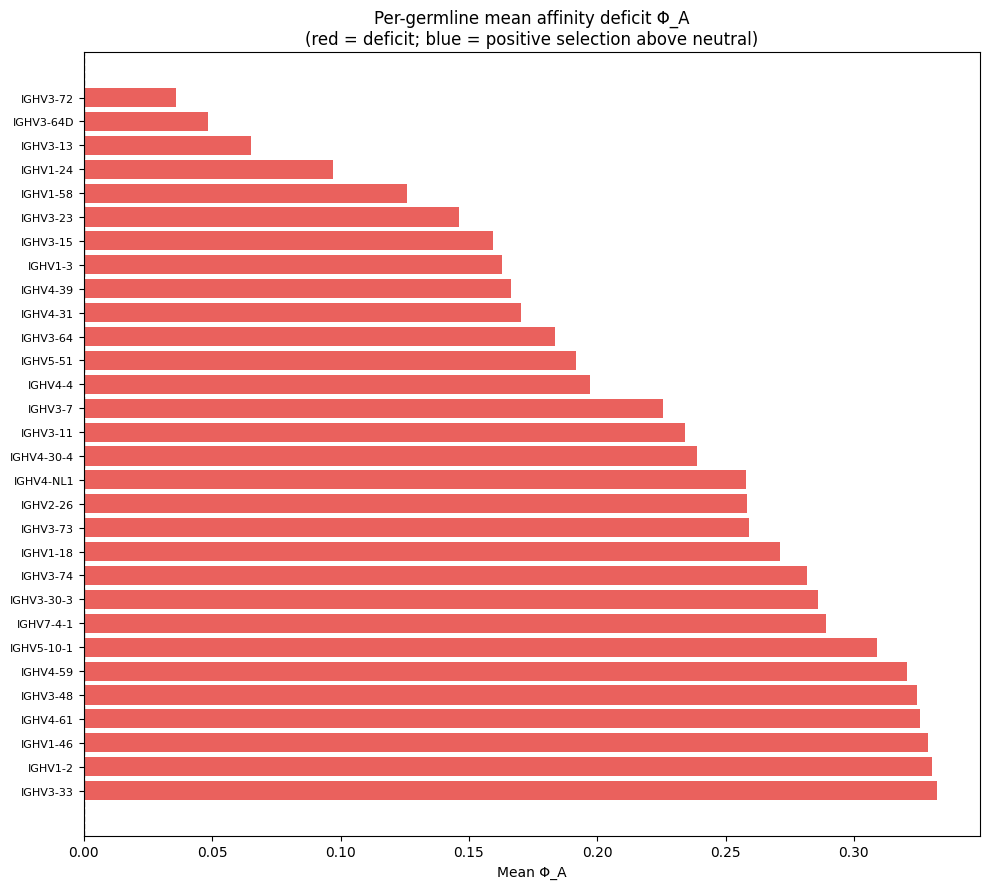

Saved.


In [8]:
# ── Per-germline mean phi_A (≥1000 sequences) ────────────────────────────────
germ_phi = (
    valid
    .group_by('v_gene:0')
    .agg([
        pl.col('phi_A').mean().alias('mean_phi_A'),
        pl.col('phi_A').median().alias('median_phi_A'),
        pl.col('delta_RS_H').mean().alias('mean_delta_RS'),
        pl.len().alias('n'),
    ])
    .filter(pl.col('n') >= 1000)
    .sort('mean_phi_A')
)
germ_phi.write_csv(FIGURES / "fig_a1_phi_a_by_germline.csv")
print(f"Germlines with ≥1000 memory sequences: {germ_phi.height}")

top_n = min(30, germ_phi.height)
genes  = germ_phi['v_gene:0'].to_list()[:top_n]
means  = germ_phi['mean_phi_A'].to_numpy()[:top_n]
colors = ['#E53935' if v > 0 else '#1E88E5' for v in means]

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))
ax.barh(range(top_n), means[::-1], color=colors[::-1], alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(genes[::-1], fontsize=8)
ax.axvline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Mean Φ_A')
ax.set_title(f'Per-germline mean affinity deficit Φ_A\n(red = deficit; blue = positive selection above neutral)')
plt.tight_layout()
plt.savefig(FIGURES / "fig_a1_phi_a_by_germline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## A2 — Convergent Response Analysis (Cross-Donor Sharing)

**Biological question:** How many independent donors produce a memory B cell with the same antigen-contact fingerprint — defined as (V-gene + CDRH3 amino acid sequence)?

A (V-gene, CDRH3_aa) group present in ≥3 donors is a **convergent response**: the same epitope has independently recruited structurally similar antibodies across individuals, the strongest available evidence for antigen-driven selection.

**Unit of analysis: DONOR.** Each donor casts one vote per (V-gene, CDRH3_aa) group — regardless of how many memory cells or clonal lineages carry that fingerprint. The vote is binary: does this donor's memory repertoire contain this response or not? This is achieved by a single `unique(subset=['donor', 'v_gene:0', 'junction_aa:0'])` before counting donors. All memory cells are retained for downstream Φ_A comparisons.

**Why (V-gene + CDRH3_aa) and not the `clonotype` field?**

The `clonotype` field groups sequences by VH + VL + JH + JL + exact CDRH3. This definition is too restrictive for cross-donor memory comparison for two reasons:
1. **VL is not required for convergence:** the same epitope can recruit responses from different light-chain genes. VH (via CDR1/CDR2) and CDRH3 are the dominant antigen-contact determinants. Requiring VL+JL match would miss many convergent responses where the heavy chain is shared but the light chain varies.
2. **Amino acid level vs nucleotide level:** in memory, SHM has introduced silent (synonymous) nucleotide variants across clonal families and across donors. Two cells in different donors responding to the same epitope can produce the same CDR3 amino acid loop while differing at the nucleotide level. Grouping at amino acid level correctly identifies these as the same functional response.

**Why V-gene is included:** CDR1 and CDR2 are encoded by the V-gene and contribute to the paratope. The same CDRH3 on two different V-genes produces a different binding surface. Including V-gene is standard in the field (public clonotype literature uses VH + CDRH3_aa as the minimal convergence unit).

**Note on `clonotype` in the naive compartment:** In naive B cells, the correct use of `clonotype` (exact VH+VL+JH+JL+CDRH3) is to identify *recurring RAG recombinations* — the same VDJ rearrangement arising independently by chance in multiple donors. This is a distinct biological phenomenon from convergent antigen selection and does not apply to memory B cells (which have undergone SHM).

In [ ]:
PUBLIC_THRESHOLD = 3

# ── Donor-level convergence counting ─────────────────────────────────────────
# Biological question: how many donors independently produce this response?
# Each donor votes once per (v_gene, CDRH3_aa) — one deduplication step only.
# All memory cells are kept; the unique() merely prevents a single donor with
# 1000 cells of the same CDRH3 from counting as 1000 donors.

cdrh3_donor_counts = (
    memory
    .select(['donor', 'v_gene:0', 'junction_aa:0', 'cdrh3_length'])
    .drop_nulls(subset=['donor', 'v_gene:0', 'junction_aa:0'])
    .unique(subset=['donor', 'v_gene:0', 'junction_aa:0'])   # one vote per donor
    .group_by(['v_gene:0', 'junction_aa:0'])
    .agg([
        pl.len().alias('n_donors'),
        pl.col('cdrh3_length').first().alias('cdrh3_length'),
    ])
)

print(f"Distinct (V-gene, CDRH3_aa) groups: {cdrh3_donor_counts.height:,}")
print(f"\nDonor count distribution:")
print(
    cdrh3_donor_counts.group_by('n_donors')
    .agg(pl.len().alias('n_groups'))
    .sort('n_donors')
)

# Label public / private
cdrh3_type = cdrh3_donor_counts.with_columns(
    pl.when(pl.col('n_donors') >= PUBLIC_THRESHOLD)
    .then(pl.lit('public'))
    .otherwise(pl.lit('private'))
    .alias('convergence_type')
)

n_public = cdrh3_type.filter(pl.col('convergence_type') == 'public').height
print(f"\nPublic (V-gene, CDRH3_aa) groups (≥{PUBLIC_THRESHOLD} donors): {n_public:,}")
print(f"Private: {cdrh3_type.filter(pl.col('convergence_type') == 'private').height:,}")

In [ ]:
# Join convergence labels to phi_A dataframe via (v_gene:0, junction_aa:0)
phi_a_conv = (
    phi_a_df
    .join(
        cdrh3_type.select(['v_gene:0', 'junction_aa:0', 'n_donors', 'convergence_type']),
        on=['v_gene:0', 'junction_aa:0'],
        how='left'
    )
    .with_columns(
        pl.col('convergence_type').fill_null('private')  # sequences not in lineage_reps = private
    )
    .filter(pl.col('phi_A').is_not_null())
)

comparison = (
    phi_a_conv
    .group_by('convergence_type')
    .agg([
        pl.col('phi_A').mean().alias('mean_phi_A'),
        pl.col('phi_A').median().alias('median_phi_A'),
        pl.col('delta_RS_H').mean().alias('mean_delta_RS'),
        pl.col('n_mut_H').mean().alias('mean_n_mut_H'),
        pl.col('cdrh3_length').mean().alias('mean_cdrh3_len'),
        pl.len().alias('n_sequences'),
    ])
    .sort('convergence_type')
)
print("Public vs private comparison (lineage-deduped, V-gene+CDRH3_aa groups):")
print(comparison)

# Top public groups by n_donors
top_public = (
    cdrh3_type.filter(pl.col('convergence_type') == 'public')
    .sort('n_donors', descending=True)
    .head(20)
)
print("\nTop 20 most convergent (V-gene, CDRH3_aa) groups:")
print(top_public)

In [ ]:
# Save public convergent CDRH3 table (isotype at class level via phi_a_df join)
public_conv_table = (
    cdrh3_type.filter(pl.col('convergence_type') == 'public')
    .sort('n_donors', descending=True)
    .join(
        # Add dominant isotype class (collapsed) from memory sequences matching (v_gene, junction_aa)
        memory.group_by(['v_gene:0', 'junction_aa:0']).agg([
            pl.col('isotype_class').mode().first().alias('dominant_isotype_class'),
            pl.col('n_mut_H').mean().round(2).alias('mean_n_mut_H'),
            pl.len().alias('n_memory_sequences'),
        ]),
        on=['v_gene:0', 'junction_aa:0'],
        how='left'
    )
)
public_conv_table.write_csv(TABLES / "public_clonotypes.csv")
print(f"Saved → {TABLES}/public_clonotypes.csv")
print(f"Public convergent CDRH3 groups: {public_conv_table.height:,}")
print(public_conv_table.head(10))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

public_phi  = phi_a_conv.filter(pl.col('convergence_type') == 'public')['phi_A'].to_numpy()
private_phi = phi_a_conv.filter(pl.col('convergence_type') == 'private')['phi_A'].to_numpy()

# phi_A distributions
ax = axes[0]
bins = np.linspace(-3, 3, 60)
ax.hist(np.clip(private_phi, -3, 3), bins=bins, density=True,
        color='#90CAF9', alpha=0.7, label=f'Private (n={len(private_phi):,})')
ax.hist(np.clip(public_phi, -3, 3), bins=bins, density=True,
        color='#EF5350', alpha=0.7, label=f'Public (n={len(public_phi):,})')
ax.axvline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Φ_A')
ax.set_ylabel('Density')
ax.set_title('Φ_A: convergent vs private\n(lineage-deduped, V+CDRH3_aa groups)')
ax.legend(fontsize=8)

# n_mut_H distributions
ax2 = axes[1]
public_nmut  = phi_a_conv.filter(pl.col('convergence_type') == 'public')['n_mut_H'].to_numpy()
private_nmut = phi_a_conv.filter(pl.col('convergence_type') == 'private')['n_mut_H'].to_numpy()
bins2 = np.arange(0, 50)
ax2.hist(private_nmut, bins=bins2, density=True, color='#90CAF9', alpha=0.7, label='Private')
ax2.hist(public_nmut,  bins=bins2, density=True, color='#EF5350', alpha=0.7, label='Public')
ax2.set_xlabel('n_mut_H (VH mutations)')
ax2.set_ylabel('Density')
ax2.set_title('VH mutation load: convergent vs private')
ax2.legend(fontsize=8)

# n_donors distribution for public groups
ax3 = axes[2]
nd = cdrh3_type.filter(pl.col('convergence_type') == 'public')['n_donors'].to_numpy()
ax3.hist(nd, bins=range(PUBLIC_THRESHOLD, int(nd.max())+2), color='#EF5350', alpha=0.8)
ax3.set_xlabel('Number of donors sharing (V-gene, CDRH3_aa)')
ax3.set_ylabel('Number of convergent groups')
ax3.set_title('Convergent response donor breadth')
ax3.set_yscale('log')

plt.tight_layout()
plt.savefig(FIGURES / "fig_a2_public_clonotypes.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## A3 — Isotype-Stratified Affinity Proxy (Within Lineages)

Within clonal lineages (B-cell families derived from a common ancestor), IgG/IgA class-switched members have undergone deeper GC maturation than IgM members. Mutations **enriched in class-switched vs unswitched members of the same lineage** are therefore candidates for affinity-selected mutations.

**Method:**
1. Filter lineages containing both IgM and IgG/IgA members (clonal families that span a class-switch event)
2. Compute Φ_A per sequence and compare IgM vs IgG/IgA within each lineage
3. At the summary level: for each IGHV germline, what is the mean Φ_A shift from IgM to IgG?

For the full positional analysis (which specific IMGT positions accumulate affinity-selected mutations), the iggnition-aligned nt arrays are needed — that analysis is performed in Step 5 (Lagrange) where the per-mutation ΔΦ_A contributions are computed.

**Isotype ordering (from Step 1 V4):** IgM ≈ null < IgE < IgA ≈ IgG (by mean n_mut_H). IgG is used as the "deep maturation" comparator.

In [ ]:
# ── Identify lineages with both IgM and IgG members ──────────────────────────
# isotype_class is already collapsed (IgG, IgA, IgM) from the isotype collapse cell.
# phi_a_df carries isotype_class directly.

phi_a_iso = phi_a_df.filter(
    pl.col('phi_A').is_not_null() & pl.col('lineage').is_not_null()
)

# For each lineage, check which isotype classes are present
lineage_iso_presence = (
    phi_a_iso.filter(pl.col('isotype_class').is_in(['IgM', 'IgG', 'IgA']))
    .group_by('lineage')
    .agg([
        pl.col('isotype_class').unique().alias('isotypes_present'),
        pl.len().alias('n_members'),
    ])
)

# Lineages with BOTH IgM and IgG (class-switch event within the lineage)
mixed_IgM_IgG = (
    lineage_iso_presence
    .filter(
        pl.col('isotypes_present').list.contains('IgM') &
        pl.col('isotypes_present').list.contains('IgG')
    )
)
print(f"Lineages with both IgM and IgG members: {mixed_IgM_IgG.height:,}")
print(f"Total sequences in these mixed lineages:")
print(
    phi_a_iso
    .filter(pl.col('lineage').is_in(mixed_IgM_IgG['lineage'].to_list()))
    .group_by('isotype_class')
    .agg(pl.len().alias('n'))
    .sort('n', descending=True)
)

In [14]:
# ── Compute phi_A shift IgM → IgG within mixed lineages ──────────────────────
mixed_lineage_list = mixed_IgM_IgG['lineage'].to_list()

mixed_seqs = phi_a_iso.filter(
    pl.col('lineage').is_in(mixed_lineage_list) &
    pl.col('isotype_class').is_in(['IgM', 'IgG'])
)

# Per-lineage mean phi_A by isotype class
lineage_means = (
    mixed_seqs
    .group_by(['lineage', 'isotype_class'])
    .agg([
        pl.col('phi_A').mean().alias('mean_phi_A'),
        pl.col('delta_RS_H').mean().alias('mean_delta_RS'),
        pl.col('n_mut_H').mean().alias('mean_n_mut'),
        pl.len().alias('n'),
    ])
)

# Pivot to wide format for comparison
igm_means = lineage_means.filter(pl.col('isotype_class') == 'IgM').select(
    ['lineage', pl.col('mean_phi_A').alias('phi_A_IgM'),
     pl.col('mean_n_mut').alias('n_mut_IgM'), pl.col('n').alias('n_IgM')]
)
igg_means = lineage_means.filter(pl.col('isotype_class') == 'IgG').select(
    ['lineage', pl.col('mean_phi_A').alias('phi_A_IgG'),
     pl.col('mean_n_mut').alias('n_mut_IgG'), pl.col('n').alias('n_IgG')]
)

lineage_compare = (
    igm_means.join(igg_means, on='lineage', how='inner')
    .with_columns(
        (pl.col('phi_A_IgG') - pl.col('phi_A_IgM')).alias('delta_phi_A_IgG_minus_IgM')
    )
    .filter(
        (pl.col('n_IgM') >= 2) & (pl.col('n_IgG') >= 2)  # need ≥2 members per class
    )
    .sort('delta_phi_A_IgG_minus_IgM')
)

print(f"Lineages with ≥2 IgM and ≥2 IgG members: {lineage_compare.height:,}")
print(f"\nMean delta_phi_A (IgG − IgM): {lineage_compare['delta_phi_A_IgG_minus_IgM'].mean():.4f}")
print(f"Fraction of lineages where IgG has lower phi_A than IgM (more affinity-selected):")
print(f"  {(lineage_compare['delta_phi_A_IgG_minus_IgM'] < 0).mean():.3f}")

print("\nTop 10 lineages with largest IgG affinity improvement (most negative delta):")
print(lineage_compare.head(10))

lineage_compare.write_csv(TABLES / "affinity_selected_mutations.csv")
print(f"\nSaved → {TABLES}/affinity_selected_mutations.csv")

Lineages with ≥2 IgM and ≥2 IgG members: 192

Mean delta_phi_A (IgG − IgM): -0.0688
Fraction of lineages where IgG has lower phi_A than IgM (more affinity-selected):
  0.531

Top 10 lineages with largest IgG affinity improvement (most negative delta):
shape: (10, 8)
┌─────────────────┬───────────┬───────────┬───────┬───────────┬───────────┬───────┬────────────────┐
│ lineage         ┆ phi_A_IgM ┆ n_mut_IgM ┆ n_IgM ┆ phi_A_IgG ┆ n_mut_IgG ┆ n_IgG ┆ delta_phi_A_Ig │
│ ---             ┆ ---       ┆ ---       ┆ ---   ┆ ---       ┆ ---       ┆ ---   ┆ G_minus_IgM    │
│ str             ┆ f64       ┆ f64       ┆ u32   ┆ f64       ┆ f64       ┆ u32   ┆ ---            │
│                 ┆           ┆           ┆       ┆           ┆           ┆       ┆ f64            │
╞═════════════════╪═══════════╪═══════════╪═══════╪═══════════╪═══════════╪═══════╪════════════════╡
│ purse_west_cere ┆ 3.589741  ┆ 6.0       ┆ 2     ┆ -0.1333   ┆ 18.0      ┆ 2     ┆ -3.723041      │
│ al_spread_decid ┆       

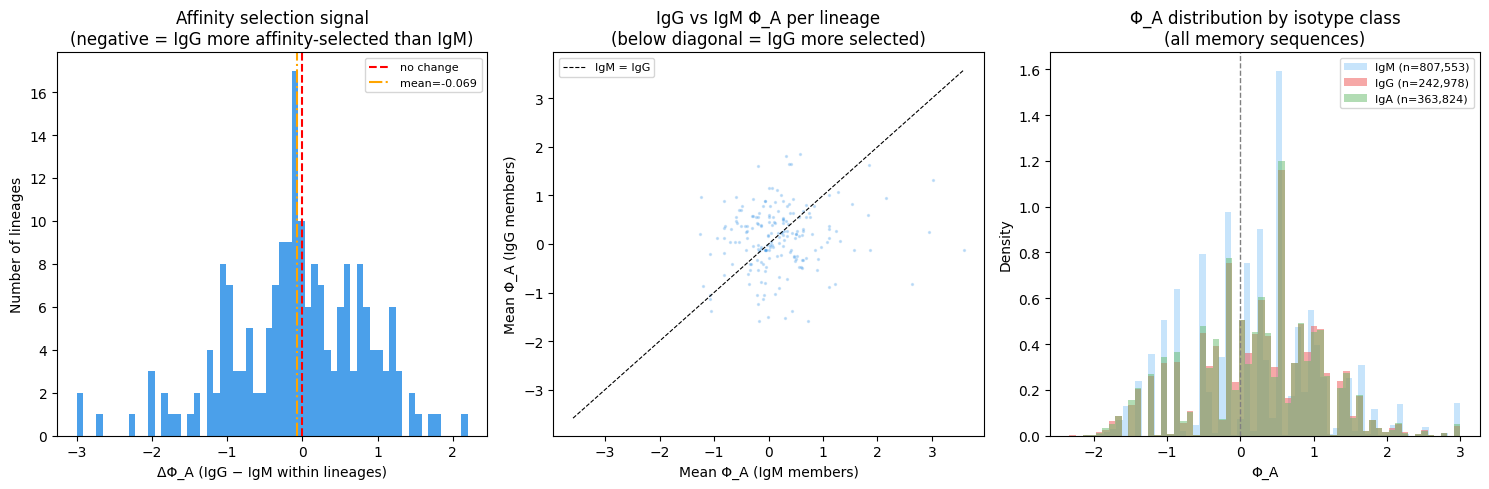

Saved.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

delta = lineage_compare['delta_phi_A_IgG_minus_IgM'].to_numpy()

# Left: histogram of delta_phi_A
ax = axes[0]
ax.hist(np.clip(delta, -3, 3), bins=60, color='#1E88E5', alpha=0.8)
ax.axvline(0, color='red', lw=1.5, linestyle='--', label='no change')
ax.axvline(delta.mean(), color='orange', lw=1.5, linestyle='-.', label=f'mean={delta.mean():.3f}')
ax.set_xlabel('ΔΦ_A (IgG − IgM within lineages)')
ax.set_ylabel('Number of lineages')
ax.set_title('Affinity selection signal\n(negative = IgG more affinity-selected than IgM)')
ax.legend(fontsize=8)

# Middle: IgG vs IgM phi_A scatter
ax2 = axes[1]
igm_v = lineage_compare['phi_A_IgM'].to_numpy()
igg_v = lineage_compare['phi_A_IgG'].to_numpy()
lim = max(abs(igm_v).max(), abs(igg_v).max())
ax2.scatter(igm_v, igg_v, s=2, alpha=0.2, color='#1E88E5')
ax2.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='IgM = IgG')
ax2.set_xlabel('Mean Φ_A (IgM members)')
ax2.set_ylabel('Mean Φ_A (IgG members)')
ax2.set_title('IgG vs IgM Φ_A per lineage\n(below diagonal = IgG more selected)')
ax2.legend(fontsize=8)

# Right: phi_A by isotype_class (all memory)
ax3 = axes[2]
for cls, color in [('IgM', '#90CAF9'), ('IgG', '#EF5350'), ('IgA', '#66BB6A')]:
    arr = phi_a_iso.filter(pl.col('isotype_class') == cls)['phi_A'].to_numpy()
    ax3.hist(np.clip(arr, -3, 3), bins=60, density=True,
             color=color, alpha=0.5, label=f'{cls} (n={len(arr):,})')
ax3.axvline(0, color='gray', linestyle='--', lw=1)
ax3.set_xlabel('Φ_A')
ax3.set_ylabel('Density')
ax3.set_title('Φ_A distribution by isotype class\n(all memory sequences)')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "fig_a3_isotype_affinity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

Germlines with ≥10 mixed lineages: 8

Top 10 germlines with strongest IgG affinity improvement:
shape: (8, 4)
┌──────────┬────────────┬──────────────┬────────────┐
│ v_gene   ┆ mean_delta ┆ median_delta ┆ n_lineages │
│ ---      ┆ ---        ┆ ---          ┆ ---        │
│ str      ┆ f64        ┆ f64          ┆ u32        │
╞══════════╪════════════╪══════════════╪════════════╡
│ IGHV4-39 ┆ -0.52391   ┆ -0.437756    ┆ 11         │
│ IGHV3-23 ┆ -0.380947  ┆ -0.331934    ┆ 11         │
│ IGHV3-48 ┆ -0.263182  ┆ -0.01815     ┆ 21         │
│ IGHV5-51 ┆ -0.132603  ┆ -0.170316    ┆ 17         │
│ IGHV3-74 ┆ 0.048888   ┆ 0.022568     ┆ 29         │
│ IGHV3-7  ┆ 0.180599   ┆ 0.394698     ┆ 20         │
│ IGHV1-18 ┆ 0.263604   ┆ 0.765611     ┆ 11         │
│ IGHV3-53 ┆ 0.278659   ┆ 0.080642     ┆ 12         │
└──────────┴────────────┴──────────────┴────────────┘


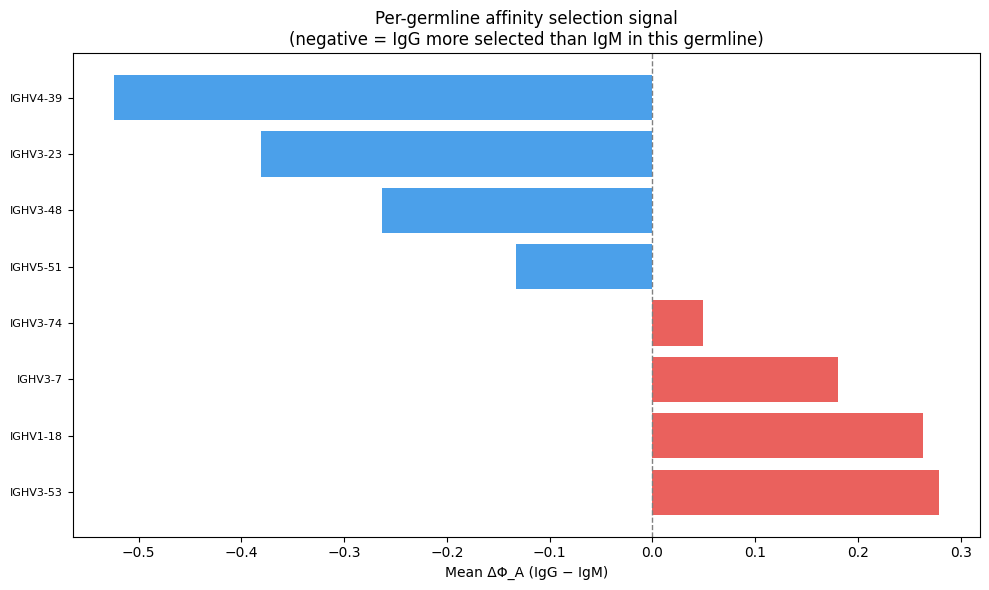

Saved.


In [16]:
# ── Per-germline phi_A shift IgM → IgG ───────────────────────────────────────
# Stratify the within-lineage delta_phi_A by germline gene to identify which
# germlines show the strongest affinity-driven selection signal

lineage_vgene = (
    mixed_seqs.filter(pl.col('isotype_class') == 'IgM')
    .group_by('lineage')
    .agg(pl.col('v_gene:0').first().alias('v_gene'))
)

lineage_compare_vg = lineage_compare.join(lineage_vgene, on='lineage', how='left')

germline_shift = (
    lineage_compare_vg.filter(pl.col('v_gene').is_not_null())
    .group_by('v_gene')
    .agg([
        pl.col('delta_phi_A_IgG_minus_IgM').mean().alias('mean_delta'),
        pl.col('delta_phi_A_IgG_minus_IgM').median().alias('median_delta'),
        pl.len().alias('n_lineages'),
    ])
    .filter(pl.col('n_lineages') >= 10)
    .sort('mean_delta')
)

germline_shift.write_csv(TABLES / "phi_A_shift_by_germline.csv")
print(f"Germlines with ≥10 mixed lineages: {germline_shift.height}")
print("\nTop 10 germlines with strongest IgG affinity improvement:")
print(germline_shift.head(10))

# Plot
top_n = min(30, germline_shift.height)
genes  = germline_shift['v_gene'].to_list()[:top_n]
deltas = germline_shift['mean_delta'].to_numpy()[:top_n]
colors = ['#1E88E5' if v < 0 else '#E53935' for v in deltas]

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))
ax.barh(range(top_n), deltas[::-1], color=colors[::-1], alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(genes[::-1], fontsize=8)
ax.axvline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Mean ΔΦ_A (IgG − IgM)')
ax.set_title('Per-germline affinity selection signal\n(negative = IgG more selected than IgM in this germline)')
plt.tight_layout()
plt.savefig(FIGURES / "fig_a3_delta_phi_A_by_germline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Step 3 Summary

| Calculation | Output table | Output figure(s) |
|-------------|-------------|------------------|
| A1: per-sequence Φ_A | `affinity_proxy.parquet` | `fig_a1_phi_a_distributions.png`, `fig_a1_phi_a_by_germline.png` |
| A2: convergent responses | `public_clonotypes.csv` | `fig_a2_public_clonotypes.png` |
| A3: isotype-stratified affinity | `affinity_selected_mutations.csv`, `phi_A_shift_by_germline.csv` | `fig_a3_isotype_affinity.png`, `fig_a3_delta_phi_A_by_germline.png` |

**Key formulae:**
```
RS_neutral = Σ_{i∈CDR1+CDR2} (s5f_weight_i × e_dN_frac_i) / Σ (s5f_weight_i × e_dS_frac_i)
δ_RS(x)    = (n_R_CDR_H / (n_S_CDR_H + 0.5)) / RS_neutral
Φ_A(x)     = −log(δ_RS(x) + ε)    [positive = deficit; negative = positive selection]
```

**Corrections applied (v2):**
1. **Isotype collapse:** `c_gene:0` subclasses (IGHG1/2/3/4 → IgG, IGHA1/2 → IgA) collapsed immediately after loading. Sequencing-based subclass assignment is unreliable; all calculations operate at class level.
2. **Calculation verification:** φ_A formula verified correct. ε=1e-3 added to δ_RS (not to numerator/denominator), giving max φ_A ≈ 6.9 for all-silent CDR sequences. Pseudocount 0.5 on S_CDR denominator stabilises low-mutation sequences. φ_A ≈ 0 at neutral δ_RS=1. ✓
3. **A2 biology fix:** Replaced `clonotype`-based donor counting with lineage-deduped (V-gene, CDRH3_aa) cross-donor grouping. Memory B-cell convergence is now assessed one vote per clonal lineage per donor, respecting that `lineage` is the correct unit for memory compartment analyses. `clonotype` (exact VH+VL+JH+JL+CDRH3) is reserved for naive recurring recombination analyses.

**Adaptations from Step 2:**
- CDR1 under purifying selection → RS_neutral is S5F-weighted (captures CDR1 lower R/S capacity)
- No VH-VL coupling correction needed (Step 2 showed Φ_S^interface = 0)
- Positions with s5f_weight=0 excluded from RS_neutral (Trp/Met zero-synonymous positions)

**Next step:** `04_phi_reactivity.ipynb` — Reactivity risk Φ_R (R1–R2)